# Decision Tree
##  Titanic Dataset

This notebook introduces the **Decision Tree**, explains the theory behind it, and walks through a complete example using the classic Titanic dataset.

We will cover:
- What is a decision tree, and how does it make a classification decision
- Exploring the Titanic dataset
- Preparing the data for modeling
- Spliting the data into training (80%) and test (20%) sets
- Learning splitting criteria: Gini impurity, Entropy and Information Gain
- Training, inspecting the learned parameters, and evaluating the model
- Control overfitting by tuning tree depth
- Learning feature importance and interpretability

## Q1. What is a decision tree?
A decision tree is a flowchart‑like model used for classification or regression. It predicts outcomes (e.g., survival on the Titanic) by splitting data into branches based on feature values (passenger features).

### Key Components
- **Root Node** → The starting point of the tree (first feature used to split).
Example: “Is sex = female?” when predicting Titanic survival.

- **Decision/Internal Node** → A point where the tree asks a question about a feature.
Example: “Is age < 10?”

- **Branch** → The path taken depending on the answer (Yes or No).

- **Leaf Node** → The final node that gives a prediction.
Example: “Survived” or “Did not survive.”

### How does decision tree make a classification decision?
1. The tree begins at the **root node**.
2. It asks a **yes/no question** about one feature (e.g., Is passenger female?).
3. Based on the answer, the passenger follows a **branch** to the next node.
4. At each **internal node**, another question is asked (e.g., Is age < 10?).
5. Eventually, the passenger reaches a **leaf node**, which contains the final prediction (e.g., Survived).

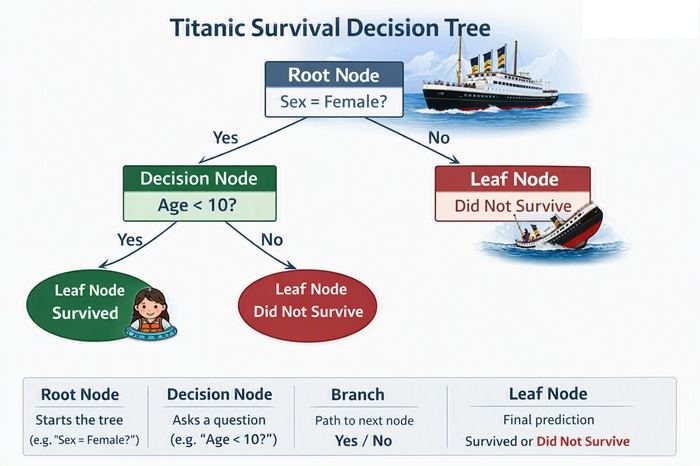

## Q2. Load and Explore the Titanic Dataset
The Titanic dataset contains information about passengers aboard the Titanic’s maiden voyage in 1912. Details about 891 passangers are described by a mix of **categorical** and **continuous** variables:

- **PassengerId** → Unique identifier  
- **Pclass** → Ticket class (1st, 2nd, 3rd)  
- **Name** → Passenger’s name  
- **Sex** → Male or female  
- **Age** → Age in years (continuous, with some missing values)  
- **SibSp** → Number of siblings/spouses aboard  
- **Parch** → Number of parents/children aboard  
- **Ticket** → Ticket number  
- **Fare** → Ticket fare (continuous, in British pounds)  
- **Cabin** → Cabin number (many missing values)  
- **Embarked** → Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

There are two classes:
- **Survived** (1)
- **Did not survive** (0)




In [ ]:
# Import the libraries seaborn, pandas


In [ ]:
# Load Titanic dataset


In [ ]:
# Shape of the data


In [ ]:
# List of columns
print("Columns:", titanic.columns.tolist())

In [ ]:
# Missing values per column


In [ ]:
# Class balance of 'survived'
class_counts = titanic['survived'].value_counts()
class_percentages = titanic['survived'].value_counts(normalize=True) * 100
print("\nClass balance (counts):\n", class_counts)
print("\nClass balance (percentages):\n", class_percentages)

## Q3. Prepare the data for modeling.


In [ ]:
# Step 1: Select Relevant Features
#use a subset that captures passenger demographics and travel details

features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
titanic = titanic[features + ['survived']]

In [ ]:
# Step 2: Handle Missing Values
# Age → Fill missing values with median (reasonable for numeric data).
# Embarked → Fill missing values with mode (most frequent port).




In [ ]:
# Step 3: Encode Categorical Columns
# Convert text categories (sex, embarked) into numeric codes:

titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})

titanic['embarked'] = titanic['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

X = titanic[features]
y = titanic['survived']

### Why Decision Trees Don’t Need Feature Scaling

Unlike algorithms such as **Logistic Regression** or **SVM**, decision trees:
- Split data based on **thresholds** (e.g., *Is age < 10?*), not on distances or magnitudes.
- The **ordering** of values matters, not their absolute scale.
- Whether **age** is measured in years or months doesn’t change the split logic — the tree still finds the best threshold that separates classes.


Decision trees look at **relative comparisons**, not numerical magnitudes. Scaling (like StandardScaler) does not affect how splits are chosen, because the tree only cares about which side of a threshold each sample falls on.



## Q4. Train/Test Split and Decision Tree Model

In [ ]:
# Step 1: Split the Data

# import train_test_split from sklearn.model_selection
from sklearn.model_selection import train_test_split

# Split data
# use 80% for training and 20% for testing, keeping the class balance consistent with `stratify=y`.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



In [ ]:
#Step 2: Fit the Decision Tree

# import DecisionTreeClassifier, plot_tree from sklearn.tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

# import matplotlib.pyplot
import matplotlib.pyplot as plt

# train the model


In [ ]:
# Step 3: Visualize the Tree
plt.figure(figsize=(16, 8))
plot_tree(model, feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True)
plt.show()

### Interpretation

- **Root Node Feature**: In most Titanic runs, the root split is **`sex`**.  
  The tree first asks: *Is passenger female?*  
  - If **Yes**, most survived.  
  - If **No**, survival chances drop sharply.

The model found **gender** to be the most informative feature overall. It provides the clearest separation between survivors and non‑survivors.  
This aligns with historical context: women and children were prioritized during evacuation (“women and children first”).


## Pure vs. Impure Nodes

To understand splitting metrics, students must first understand node purity:

Pure Node: A node containing items belonging to only one class (e.g., all 10 items are "Class A").

Purity = Maximum | Impurity = 0

Impure Node: A node containing a mix of multiple classes (e.g., 5 "Class A" items and 5 "Class B" items).

Purity = Minimum | Impurity = Maximum

The primary objective of every split in a decision tree is to turn impure parent nodes into purer child nodes.

## Gini Index (Gini Impurity)

Definition: A metric that measures the likelihood that a randomly chosen element from a dataset would be incorrectly labeled if it were randomly labeled according to the class distribution of that subset.Focus: It measures misclassification probability.Formula:$$Gini = 1 - \sum_{i=1}^{C} p_i^2$$

Key Values (Binary Classification):

$0.0$ $\rightarrow$ Completely pure node.

$0.5$ $\rightarrow$ Maximum impurity (perfect 50/50 mix).

Takeaway: Gini asks, "If I randomly pick an item and randomly guess its label based on current proportions, how often will I be wrong?"

## Entropy

Definition: A metric originating from Information Theory that measures the degree of randomness, disorder, or uncertainty within a node.

Focus: It measures disorder/chaos.Formula:

$$Entropy = -\sum_{i=1}^{C} p_i \log_2(p_i)

$$Key Values (Binary Classification):

$0.0$ $\rightarrow$ Completely pure node (zero uncertainty).

$1.0$ $\rightarrow$ Maximum disorder (complete uncertainty, 50/50 mix).

Takeaway: Entropy asks, "How much chaos or unpredictable noise is currently inside this node?"

## Information Gain (IG)

Definition: The net reduction in entropy achieved by splitting a parent node on a specific feature.

Focus: It measures the usefulness of a feature for separating classes.

Formula:

$$IG = Entropy_{\text{parent}} - Entropy_{\text{children (weighted average)}}

$$Key Behavior:

High Information Gain $\rightarrow$ Excellent split feature.

Low Information Gain $\rightarrow$ Poor split feature.

Takeaway: Information Gain asks, "How much chaos did we eliminate by splitting on this feature?

## Q5. Splitting criteria: Gini impurity.

   Gini impurity measures how “mixed” the classes are in a node.  
  - A node is **pure** if all samples belong to one class → Gini = 0.  
  - A node is **impure** if samples are split across classes → higher Gini.  

**Formula**:  
  $
  Gini = 1 - \sum (p_i^2)
  $  
  where $p_i$ is the proportion of samples belonging to class \(i\).

**How Trees Use It**:  
  At each node, the tree evaluates possible splits (feature + threshold).  
  - It calculates the Gini impurity for the resulting child nodes.  
  - The split that **reduces impurity the most** (i.e., makes child nodes purer) is chosen.  
  - This ensures the tree keeps separating classes more cleanly as it grows.

## Numeric Example

Suppose a node contains:
- 10 passengers who **survived**  
- 5 passengers who **did not survive**  
- Total = 15 samples

## Step 1: Compute Class Probabilities
- $p_{survived} = \frac{10}{15} = 0.667$  
- $p_{not\_survived} = \frac{5}{15} = 0.333$

## Step 2: Apply Formula
$
Gini = 1 - (p_{survived}^2 + p_{not\_survived}^2)
$

$
Gini = 1 - (0.667^2 + 0.333^2)
$

$
Gini = 1 - (0.445 + 0.111)
$

$
Gini = 1 - 0.556 = 0.444
$



## What does it mean?
- A Gini impurity of **0.444** means the node is moderately impure — it contains a mix of survivors and non‑survivors.  
- If the tree finds a split (say, by sex or pclass) that separates survivors more cleanly, the child nodes will have lower Gini values.  
- The algorithm prefers such splits because they make predictions more certain.

## Q6. Splitting criteria: Entropy and Information Gain.

- **Entropy** measures the uncertainty (or disorder) in a node.  
  - Pure node (all samples same class) → Entropy = 0  
  - Mixed node → Higher entropy  

- **Formula**:  
  $
  Entropy = -\sum p_i \log_2(p_i)
  $
  where $p_i$ is the proportion of samples in class $i$.

- **Information Gain (IG)**:  
  $
  IG = Entropy(parent) - \text{Weighted Entropy(children)}
  $
  It tells us how much uncertainty is reduced by a split. The tree chooses the split with the **highest IG**.

### Step 1: Parent Node Entropy

Node contains:
- 10 survived  
- 5 did not survive  
- Total = 15  

Probabilities:  
- $p_{survived} = 10/15 = 0.667$  
- $p_{not} = 5/15 = 0.333$

$
Entropy = -(0.667 \cdot \log_2 0.667 + 0.333 \cdot \log_2 0.333)
$

$
Entropy = -(0.667 \cdot -0.585 + 0.333 \cdot -1.585)
$

$
Entropy = 0.389 + 0.528 = 0.917
$

Parent entropy ≈ **0.92**

### Step 2: Candidate Split (by Sex)

Suppose splitting by sex gives:

- **Female node**: 8 survived, 2 did not survive (10 total)  
- **Male node**: 2 survived, 3 did not survive (5 total)



### (a) Entropy of Each Child

**Female node**:  
- $p_{survived} = 0.8, p_{not} = 0.2$  
$
Entropy = -(0.8 \cdot \log_2 0.8 + 0.2 \cdot \log_2 0.2)
$
$
Entropy = -(0.8 \cdot -0.322 + 0.2 \cdot -2.322) = 0.258 + 0.464 = 0.722
$

**Male node**:  
- $p_{survived} = 0.4, p_{not} = 0.6$  
$
Entropy = -(0.4 \cdot \log_2 0.4 + 0.6 \cdot \log_2 0.6)
$
$
Entropy = -(0.4 \cdot -1.322 + 0.6 \cdot -0.737) = 0.529 + 0.442 = 0.971
$

### (b) Weighted Average Entropy

$
Weighted = \frac{10}{15} \cdot 0.722 + \frac{5}{15} \cdot 0.971
$

$
Weighted = 0.667 \cdot 0.722 + 0.333 \cdot 0.971
$

$
Weighted = 0.481 + 0.323 = 0.804
$

Weighted child entropy ≈ **0.80**

### (c) Information Gain

$
IG = Entropy(parent) - Weighted(child)
$

$
IG = 0.917 - 0.804 = 0.113
$

Information Gain ≈ **0.11**

## Interpretation
- The parent node was fairly mixed (entropy ≈ 0.92).  
- Splitting by sex reduced uncertainty slightly (IG ≈ 0.11).  
- The tree compares IG across all possible features and thresholds, and picks the split that maximizes IG.  

### # Refit a DecisionTreeClassifier with criterion='entropy' (keeping all other settings the same as Q4) and compare its root split, depth, and test accuracy to the Gini-based tree from Q4 — do the two criteria produce meaningfully different trees here?

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Fit with entropy
entropy_tree = DecisionTreeClassifier(criterion='entropy', random_state=42)
entropy_tree.fit(X_train, y_train)

# Compare to Gini-based tree
print("Gini root feature:", model.tree_.feature[0])
print("Entropy root feature:", entropy_tree.tree_.feature[0])

print("Gini depth:", model.get_depth())
print("Entropy depth:", entropy_tree.get_depth())

print("Gini test accuracy:", model.score(X_test, y_test))
print("Entropy test accuracy:", entropy_tree.score(X_test, y_test))


- On Titanic, Gini vs Entropy doesn’t matter much — both highlight gender as the strongest predictor and yield nearly identical accuracy.
- Differences in depth or accuracy are usually minor — entropy tends to produce slightly more balanced splits, while Gini is computationally faster.
- For most datasets, the choice of criterion does not meaningfully change the model’s performance.

## Q7. Generate predictions on both the training and test sets, and compute accuracy, precision, recall, and F1-score for each.
- Compare the training accuracy to the test accuracy for this unrestricted tree.
- What does a large gap between the two indicate about how the tree has fit the training data?
- Build and inspect the confusion matrix for the test set.

In [ ]:
# Import necessary packages
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Training metrics
train_acc = accuracy_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred)
train_rec = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

# Test metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred))


### Results (Unrestricted Tree)
- Training accuracy: 0.98 (good fit)

- Test accuracy: 0.82

- Precision/Recall/F1 (test): Balanced but lower than training, especially for the minority class (survived).

### Large gap between training and test accuracy indicates overfitting — the tree memorized training data patterns but struggles to generalize to unseen data.

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)


 ***Row = true class, Column = predicted class***

**Top-left (97):** correctly predicted non-survivors

**Bottom-right (50):** correctly predicted survivors

**Off-diagonal entries (13 + 19):** misclassifications

### Interpretation
- The unrestricted tree fits training data too perfectly → **overfitting.**

- On test data, it still captures the main survival patterns (especially female passengers), but misclassifies a fair number of survivors/non-survivors.

**The confusion matrix shows imbalanced errors:** more survivors are misclassified than non-survivors, reflecting the dataset’s class imbalance (62% did not survive vs 38% survived).


## Q8. Control overfitting by tuning tree depth.

- Train separate DecisionTreeClassifier models for max_depth values
ranging from 1 to 15, recording the training and test accuracy at each depth.
- Plot both curves on the same chart against max_depth.
- At what depth does the model begin to overfit (training accuracy keeps climbing while test accuracy plateaus or falls)?
- What value of max_depth would you choose, and why?

In [ ]:
import matplotlib.pyplot as plt

# Train the model at different depths

train_acc = []
test_acc = []
depths = range(1, 16)

# Loop over max_depth values from 1 to 15, record training and test accuracy
for d in depths:





In [ ]:
# Plot curves
plt.figure(figsize=(8,5))
plt.plot(depths, train_acc, label="Training Accuracy", marker='o')
plt.plot(depths, test_acc, label="Test Accuracy", marker='o')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs Depth (Titanic)")
plt.legend()
plt.show()

### Results
Shallow trees (depth 1–3) → Underfit, both training and test accuracy low (0.77–0.80).

Moderate depth (around 4–6) → Training accuracy rises (0.80–0.87), test accuracy peaks (0.77–0.80).

Deep trees (≥8) → Training accuracy keeps climbing toward 1.0, but test accuracy plateaus or drops slightly (0.82).

### Interpretation
**Overfitting begins around depth 7–8**: training accuracy continues to improve, but test accuracy no longer increases.

**Best choice: max_depth ≈ 5 or 6** → balances bias and variance, giving strong generalization without memorizing noise.

## Q9. Feature importance and interpretability.

- Using your best-performing tree from Q8, extract and plot feature_importances_ as a bar chart ranked from most to least important.
- How does interpreting a decision tree (following a path of splits) compare to interpreting a Logistic Regression coefficient or an SVM support vector, in
terms of how easily a non-technical stakeholder could follow the model's reasoning?
- What is the trade-off between that interpretability and the tree's tendency to overfit compared to those other models?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Best tree from Q8

best_tree.fit(X_train, y_train)

# Feature importances

indices = np.argsort(importances)[::-1]

In [ ]:
# Plot bar chart
plt.figure(figsize=(8,5))
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [X.columns[i] for i in indices], rotation=45)
plt.ylabel("Importance")
plt.title("Feature Importances (Titanic Decision Tree)")
plt.show()


### Ranking  for Titanic dataset
**sex** → most important (root split)

**pclass** → strong secondary feature

**age and fare** → moderate importance

**sibsp, parch, embarked** → lower importance

### Interpretability Comparison

**Decision Tree:**
- Easy to explain: “If passenger is female → predict survived; else check class…”

- Stakeholders can literally follow the path of splits like a flowchart.

- Very intuitive for non‑technical audiences.

**Logistic Regression:**

- Uses coefficients: “Being female increases survival odds by X%.”

- Requires understanding of odds ratios and linear weights.

- Less visual, but mathematically precise.

**SVM:**

- Relies on support vectors and hyperplanes.

- Harder to interpret — stakeholders can’t easily “see” why a prediction was made.

- More of a black box compared to trees.

### Trade‑off
- Decision Trees → Highly interpretable, but prone to overfitting if unrestricted.

- Logistic Regression / SVM → Less interpretable, but generally more robust and less likely to overfit.

***Pruned trees (controlled depth) give both interpretability and reasonable generalization.***